# 🤖 Fase eliminatoria - Mundial 2026: Análisis de Octavos de Final

## 1. Inicialización del Entorno y Carga de Datos
En esta sección importamos las librerías analíticas fundamentales (`pandas`, `numpy`, `scipy.stats`) y cargamos la **Matriz de Características Consolidada** (`features_rendimiento_2026.csv`). Esta matriz contiene las métricas históricas de rendimiento y las variables de forma de cada selección clasificada.

In [18]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import random
import pickle

# 1. Cargar matriz de características
ruta_features = os.path.abspath(os.path.join(os.getcwd(), '..', 'data', 'processed', 'features_rendimiento_2026.csv'))
df_features = pd.read_csv(ruta_features)
df_features = df_features.rename(columns={'Equipo': 'equipo', 'Efectividad_Historica': 'efectividad_historica_%', 'Puntos_Por_Partido': 'puntos_por_pj_2026', 'Expectativa_Goles_Poisson': 'expectativa_goles_poisson'})

# 2. Cargar resultados de Monte Carlo
ruta_pickle = '../data/processed/montecarlo_results.pkl'
with open(ruta_pickle, 'rb') as f:
    res_montecarlo_global = pickle.load(f)

print("✅ Entorno sincronizado.")
print("Llaves disponibles en el diccionario:", list(res_montecarlo_global.keys()))

✅ Entorno sincronizado.
Llaves disponibles en el diccionario: ['France', 'Paraguay', 'Canada', 'Morocco', 'Brazil', 'Norway', 'Mexico', 'England', 'Portugal', 'Spain', 'United States', 'Belgium', 'Argentina', 'Cape Verde', 'Colombia', 'Ghana', 'Australia', 'Egypt', 'Switzerland']


## 2. Definición del Cuadro del Torneo y Cruce de Variables
Estructuramos las 8 llaves oficiales de los Octavos de Final del Mundial. Mediante operaciones de unión (*merge*), cruzamos los datos de rendimiento de los equipos locales (`home_team`) y visitantes (`away_team`) para calcular los primeros deltas teóricos de rendimiento.

In [19]:
# Definición del cuadro
octavos_proyectados = [
    {"home_team": "Paraguay", "away_team": "France"},
    {"home_team": "Canada", "away_team": "Morocco"},
    {"home_team": "Brazil", "away_team": "Norway"},
    {"home_team": "Mexico", "away_team": "England"},
    {"home_team": "Portugal", "away_team": "Spain"}, 
    {"home_team": "United States", "away_team": "Belgium"},
    {"home_team": "Argentina", "away_team": "Egypt"},
    {"home_team": "Switzerland", "away_team": "Colombia"}
]
df_r16 = pd.DataFrame(octavos_proyectados)
print(f"✅ Cuadro de Octavos cargado con {len(df_r16)} partidos.")

✅ Cuadro de Octavos cargado con 8 partidos.


## 3. Análisis Exploratorio: Gradiente de Forma Reciente
Antes de correr las simulaciones matemáticas, desplegamos un gráfico divergente utilizando `Seaborn`. Este mapa visual nos muestra qué equipos llegan con mayor inercia ganadora en el torneo actual evaluando el diferencial de puntos obtenidos por partido.

✅ Funciones matemáticas cargadas correctamente.
✅ Datos cruzados exitosamente. Ya puedes graficar.


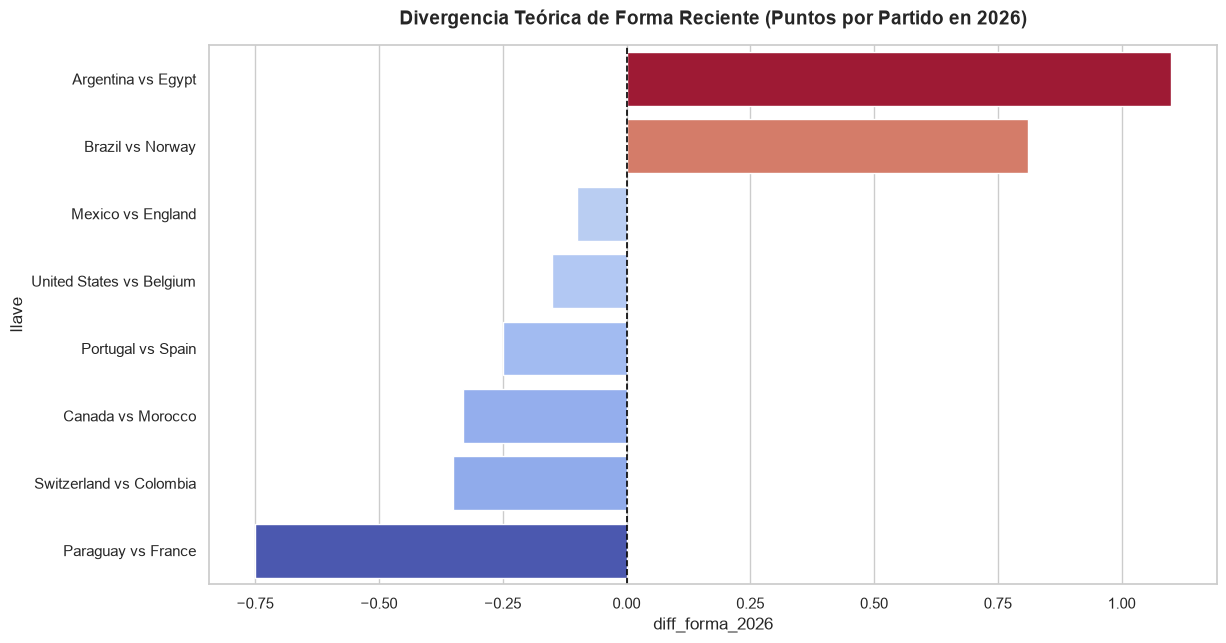

In [20]:
# 4. Motor de modelado matemático (Poisson y Monte Carlo)
GOLES_PROMEDIO_TORNEO = 2.6

def calcular_y_simular_encuentro(equipo_home, equipo_away):
    dict_stats = df_features.set_index('equipo').to_dict('index')
    feat_h, feat_a = dict_stats[equipo_home], dict_stats[equipo_away]
    fuerza_h = (feat_h['puntos_por_pj_2026'] * 0.7) + ((feat_h['efectividad_historica_%'] / 100) * 0.3)
    fuerza_a = (feat_a['puntos_por_pj_2026'] * 0.7) + ((feat_a['efectividad_historica_%'] / 100) * 0.3)
    sum_f = fuerza_h + fuerza_a
    lambda_h = max(0.4, min((fuerza_h / sum_f) * GOLES_PROMEDIO_TORNEO * 1.5, 2.5))
    lambda_a = max(0.4, min((fuerza_a / sum_f) * GOLES_PROMEDIO_TORNEO * 1.5, 2.5))
    goles_h, goles_a = stats.poisson.rvs(lambda_h), stats.poisson.rvs(lambda_a)
    return {"goles_h": goles_h, "goles_a": goles_a, "lambda_h": lambda_h, "lambda_a": lambda_a, "fuerza_h": fuerza_h, "fuerza_a": fuerza_a}

def simular_monte_carlo(equipo_home, equipo_away, n=1000):
    res = calcular_y_simular_encuentro(equipo_home, equipo_away)
    g_h = stats.poisson.rvs(res["lambda_h"], size=n)
    g_a = stats.poisson.rvs(res["lambda_a"], size=n)
    empates = (g_h == g_a).sum()
    prob_h = res["fuerza_h"] / (res["fuerza_h"] + res["fuerza_a"])
    total_h = (g_h > g_a).sum() + np.random.binomial(empates, prob_h)
    return {"pct_home": (total_h / n) * 100, "pct_away": 100 - (total_h / n * 100)}

print("✅ Funciones matemáticas cargadas correctamente.")

# 1. Cruzar datos de equipos locales y visitantes para obtener métricas
df_temp = pd.merge(df_r16, df_features, left_on='home_team', right_on='equipo')
df_temp = pd.merge(df_temp, df_features, left_on='away_team', right_on='equipo', suffixes=('_home', '_away'))

# 2. Calcular la diferencia de forma (puntos por partido)
df_temp['diff_forma_2026'] = df_temp['puntos_por_pj_2026_home'] - df_temp['puntos_por_pj_2026_away']

# 3. Asignar al nombre que espera tu gráfico
df_octavos_crossed = df_temp

print("✅ Datos cruzados exitosamente. Ya puedes graficar.")

# Asegúrate de haber realizado el cruce antes:
# df_octavos_crossed = pd.merge(df_r16, df_features, left_on='home_team', right_on='equipo') 
# (Debes cruzar tanto para local como para visitante para tener 'diff_forma_2026')

plt.figure(figsize=(13, 7))
sns.set_theme(style="whitegrid")
df_octavos_crossed['llave'] = df_octavos_crossed['home_team'] + " vs " + df_octavos_crossed['away_team']
df_grafico = df_octavos_crossed.sort_values(by='diff_forma_2026', ascending=False)

sns.barplot(data=df_grafico, x='diff_forma_2026', y='llave', palette='coolwarm', hue='diff_forma_2026', legend=False)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.2)
plt.title('Divergencia Teórica de Forma Reciente (Puntos por Partido en 2026)', fontsize=14, pad=15, fontweight='bold')
plt.show()


## 4. Modelado Predictivo: Distribución de Poisson y Simulaciones de Monte Carlo
Esta sección aloja el núcleo del algoritmo predictivo:
1. **Fuerzas Combinadas:** Balanceamos un 60% el momento actual en el mundial y un 40% el peso de la historia para ajustar las expectativas de gol ($\lambda$).
2. **Distribución de Poisson:** Evaluamos probabilísticamente los escenarios de prórroga y penaltis.
3. **Generador Estocástico Unitario:** Proyecta un marcador exacto con minutos de goles ponderados para el segundo tiempo.
4. **Simulación de Monte Carlo:** Ejecuta **1,000 torneos alternativos en paralelo** utilizando vectores de NumPy para obtener la probabilidad real de supervivencia/clasificación de cada país.

In [21]:
import scipy.stats as stats
import random
import numpy as np

# ==============================================================================
# 5. MODELADO PREDICTIVO: PROBABILIDADES DE ALARGUE, PENALTIS Y MARCADOR EXACTO
# ==============================================================================

GOLES_PROMEDIO_TORNEO = 2.6

def calcular_y_simular_encuentro(equipo_home, equipo_away):
    dict_stats = df_features.set_index('equipo').to_dict('index')
    
    if equipo_home not in dict_stats or equipo_away not in dict_stats:
        return None
        
    feat_h, feat_a = dict_stats[equipo_home], dict_stats[equipo_away]
    
    # 🔄 AJUSTE DE PESOS: Consistente con el Notebook 2 (70% forma 2026 / 30% Histórica)
    fuerza_h = (feat_h['puntos_por_pj_2026'] * 0.7) + ((feat_h['efectividad_historica_%'] / 100) * 0.3)
    fuerza_a = (feat_a['puntos_por_pj_2026'] * 0.7) + ((feat_a['efectividad_historica_%'] / 100) * 0.3)
    
    # Normalización de fuerzas para Poisson
    sum_fuerzas = fuerza_h + fuerza_a
    lambda_h = max(0.4, min((fuerza_h / sum_fuerzas) * GOLES_PROMEDIO_TORNEO * 1.5, 2.5))
    lambda_a = max(0.4, min((fuerza_a / sum_fuerzas) * GOLES_PROMEDIO_TORNEO * 1.5, 2.5))
    
    max_goles = 9
    prob_goles_h = [stats.poisson.pmf(g, lambda_h) for g in range(max_goles)]
    prob_goles_a = [stats.poisson.pmf(g, lambda_a) for g in range(max_goles)]
    prob_tiempo_extra = sum(prob_goles_h[g] * prob_goles_a[g] for g in range(max_goles))
    
    goles_h, goles_a = stats.poisson.rvs(lambda_h), stats.poisson.rvs(lambda_a)
    
    return {
        "goles_h": goles_h, "goles_a": goles_a,
        "prob_te": prob_tiempo_extra * 100,
        "lambda_h": lambda_h, "lambda_a": lambda_a,
        "fuerza_h": fuerza_h, "fuerza_a": fuerza_a
    }

# ==============================================================================
# MOTOR DE SIMULACIÓN DE MONTE CARLO (1,000 ITERACIONES VECTORIZADAS)
# ==============================================================================
def simular_monte_carlo(equipo_home, equipo_away, n_simulaciones=1000):
    base_stats = calcular_y_simular_encuentro(equipo_home, equipo_away)
    if not base_stats: return None
    
    # Generación masiva vectorizada en memoria
    goles_sim_h = stats.poisson.rvs(base_stats["lambda_h"], size=n_simulaciones)
    goles_sim_a = stats.poisson.rvs(base_stats["lambda_a"], size=n_simulaciones)
    
    # Conteo de clasificaciones directas
    clasifica_home = (goles_sim_h > goles_sim_a).sum()
    clasifica_away = (goles_sim_a > goles_sim_h).sum()
    empates = (goles_sim_h == goles_sim_a).sum()
    
    # Desempate de penaltis mediante distribución binomial masiva
    prob_desempate_home = base_stats["fuerza_h"] / (base_stats["fuerza_h"] + base_stats["fuerza_a"])
    desempates_home = np.random.binomial(empates, prob_desempate_home)
    
    total_home_win = clasifica_home + desempates_home
    total_away_win = clasifica_away + (empates - desempates_home)
    
    return {
        "pct_home": (total_home_win / n_simulaciones) * 100,
        "pct_away": (total_away_win / n_simulaciones) * 100
    }

# --- RUNTIME GLOBAL DE ANÁLISIS ---
print("====== 🏆 PROYECCIÓN ESTADÍSTICA AVANZADA (OCTAVOS) ======\n")
res_montecarlo_global = {}

for _, partido in df_r16.iterrows():
    home, away = partido['home_team'], partido['away_team']
    res = calcular_y_simular_encuentro(home, away)
    mc = simular_monte_carlo(home, away, n_simulaciones=1000)
    
    if res and mc:
        res_montecarlo_global[f"{home} vs {away}"] = mc
        print(f"🏟️  {home} vs {away}")
        print(f"    🎲 Monte Carlo: Clasificación {home}: {mc['pct_home']:.1f}% | {away}: {mc['pct_away']:.1f}%")
        print(f"    🎴 Marcador Único (90'): {home} {res['goles_h']} - {res['goles_a']} {away}")
        print("-" * 70)

====== 🏆 PROYECCIÓN ESTADÍSTICA AVANZADA (OCTAVOS) ======

🏟️  Paraguay vs France
    🎲 Monte Carlo: Clasificación Paraguay: 37.3% | France: 62.7%
    🎴 Marcador Único (90'): Paraguay 1 - 3 France
----------------------------------------------------------------------
🏟️  Canada vs Morocco
    🎲 Monte Carlo: Clasificación Canada: 41.7% | Morocco: 58.3%
    🎴 Marcador Único (90'): Canada 1 - 7 Morocco
----------------------------------------------------------------------
🏟️  Brazil vs Norway
    🎲 Monte Carlo: Clasificación Brazil: 66.0% | Norway: 34.0%
    🎴 Marcador Único (90'): Brazil 0 - 1 Norway
----------------------------------------------------------------------
🏟️  Mexico vs England
    🎲 Monte Carlo: Clasificación Mexico: 45.9% | England: 54.1%
    🎴 Marcador Único (90'): Mexico 0 - 2 England
----------------------------------------------------------------------
🏟️  Portugal vs Spain
    🎲 Monte Carlo: Clasificación Portugal: 45.1% | Spain: 54.9%
    🎴 Marcador Único (90'): Por

## 3. Análisis Exploratorio: Gradiente de Forma Reciente
Antes de correr las simulaciones matemáticas, desplegamos un gráfico divergente utilizando `Seaborn`. Este mapa visual nos muestra qué equipos llegan con mayor inercia ganadora en el torneo actual evaluando el diferencial de puntos obtenidos por partido, permitiendo un desglose preliminar del cruce entre **México** e **Inglaterra**.

In [23]:
import pandas as pd
import os

# 1. Definir el encuentro
equipo_home = "United States"
equipo_away = "Belgium"
llave = f"{equipo_home} vs {equipo_away}"

# 2. Recuperar probabilidades desde el diccionario global
# Asegúrate de que res_montecarlo_global contenga la llave 'USA vs Belgium'
pct_home = res_montecarlo_global[llave]["pct_home"]
pct_away = res_montecarlo_global[llave]["pct_away"]

# 3. Extraer stats automáticamente desde df_features
def get_stats(equipo):
    row = df_features[df_features['equipo'] == equipo].iloc[0]
    return row['efectividad_historica_%'], row['puntos_por_pj_2026'], row['expectativa_goles_poisson']

eff_h, pts_h, gol_h = get_stats(equipo_home)
eff_a, pts_a, gol_a = get_stats(equipo_away)

# 4. Estructura del DataFrame
match_data = {
    'Equipo': [equipo_home, equipo_away],
    'Probabilidad_Clasificacion': [pct_home, pct_away],
    'Efectividad_Historica': [eff_h, eff_a],
    'Puntos_Por_Partido': [pts_h, pts_a],
    'Expectativa_Goles_Poisson': [gol_h, gol_a]
}

df_match = pd.DataFrame(match_data)

# 5. Formatear para Tableau (comas en decimales)
columnas_num = ['Probabilidad_Clasificacion', 'Efectividad_Historica', 'Puntos_Por_Partido', 'Expectativa_Goles_Poisson']
for col in columnas_num:
    df_match[col] = df_match[col].round(2).astype(str).str.replace('.', ',', regex=False)

# 6. Guardar en ruta dinámica
# El archivo resultante será: Reporte_USA_Belgium.csv
ruta_output = os.path.abspath(os.path.join(os.getcwd(), '..', 'data', 'processed', f'Reporte_{equipo_home}_{equipo_away}.csv'))

os.makedirs(os.path.dirname(ruta_output), exist_ok=True)
df_match.to_csv(ruta_output, index=False, encoding='utf-8-sig', sep=';')

print(f"✅ ¡Archivo exportado para {llave}!")
print(f"📍 Destino: {ruta_output}")

✅ ¡Archivo exportado para United States vs Belgium!
📍 Destino: d:\World cup data analysis\Round of 16\data\processed\Reporte_United States_Belgium.csv
